
# Gated Attention DeepSurv


In [1]:
!pip -q install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.7 MB/s eta 0:00:00


In [2]:
# =========================
# 1. Install / import packages
# =========================
import os
import math
import json
import time
import copy
import joblib
import random
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from lifelines.utils import concordance_index


In [3]:
# =========================
# 2. Mount Google Drive
# =========================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:

# =========================
# 3. Reproducibility
# =========================
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda



## Set your dataset location

Update the path below after your teammate uploads the normalized METABRIC data to your shared Google Drive folder.

Examples:
- `/content/drive/MyDrive/ECEN766/METABRIC/metabric_normalized.npz`
- `/content/drive/MyDrive/ECEN766/METABRIC/`


In [5]:
# =========================
# 4. Data path configuration
# =========================



DATA_DIR = "/content/drive/MyDrive/ECEN766final/Processed"



# Set this to False if the parquet features are already normalized

STANDARDIZE_IN_NOTEBOOK = False



assert os.path.exists(DATA_DIR), f"Folder not found: {DATA_DIR}"
print("Found data folder:", DATA_DIR)
print("Files:", sorted(os.listdir(DATA_DIR)))


Found data folder: /content/drive/MyDrive/ECEN766final/Processed
Files: ['X_test.parquet', 'X_test2000.parquet', 'X_test500.parquet', 'X_train.parquet', 'X_train2000.parquet', 'X_train500.parquet', 'X_val.parquet', 'X_val2000.parquet', 'X_val500.parquet', 'scaler.pkl', 'scaler2000.pkl', 'scaler500.pkl', 'y_test.parquet', 'y_test2000.parquet', 'y_test500.parquet', 'y_train.parquet', 'y_train2000.parquet', 'y_train500.parquet', 'y_val.parquet', 'y_val2000.parquet', 'y_val500.parquet']


In [6]:
# =========================
# 5. Data loading helpers
# =========================


def _to_numpy(df_or_series):
    if hasattr(df_or_series, "to_numpy"):
        arr = df_or_series.to_numpy()
    else:
        arr = np.asarray(df_or_series)
    return arr

def _flatten_if_single_column(arr):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    return arr

def _extract_time_event(y_df):
    """
    Flexible parser for y parquet files.

    Supported cases:
    1) Two columns with recognizable names, e.g.:
       - time/survival_time/os_time/months
       - event/status/e/os_event
    2) Exactly two columns -> assumes:
       first column = time, second column = event
    """
    if not isinstance(y_df, pd.DataFrame):
        y_df = pd.DataFrame(y_df)

    cols_lower = {c.lower(): c for c in y_df.columns}

    possible_time = [
        "time", "t", "duration", "survival_time", "overall_survival_time",
        "os_time", "months", "time_to_event"
    ]
    possible_event = [
        "event", "e", "status", "censor", "censored", "os_event",
        "overall_survival_event"
    ]

    time_col = None
    event_col = None

    for name in possible_time:
        if name in cols_lower:
            time_col = cols_lower[name]
            break

    for name in possible_event:
        if name in cols_lower:
            event_col = cols_lower[name]
            break

    if time_col is not None and event_col is not None:
        t = y_df[time_col].to_numpy(dtype=np.float32)
        e = y_df[event_col].to_numpy(dtype=np.float32)
        return t, e

    if y_df.shape[1] == 2:
        t = y_df.iloc[:, 0].to_numpy(dtype=np.float32)
        e = y_df.iloc[:, 1].to_numpy(dtype=np.float32)
        print("[Info] y parquet has 2 columns; assuming first=time, second=event.")
        return t, e

    raise ValueError(
        "Could not infer time/event columns from y parquet. "
        f"Found columns: {list(y_df.columns)}"
    )

def load_survival_data_from_parquet(data_dir: str):
    required = [
        "X_train.parquet", "X_val.parquet", "X_test.parquet",
        "y_train.parquet", "y_val.parquet", "y_test.parquet",
    ]
    for fname in required:
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing required file: {fpath}")

    X_train_df = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
    X_val_df   = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
    X_test_df  = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

    y_train_df = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))
    y_val_df   = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))
    y_test_df  = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))

    t_train, e_train = _extract_time_event(y_train_df)
    t_val,   e_val   = _extract_time_event(y_val_df)
    t_test,  e_test  = _extract_time_event(y_test_df)

    train_data = {
        "x": _to_numpy(X_train_df).astype(np.float32),
        "t": t_train.astype(np.float32),
        "e": e_train.astype(np.float32),
    }
    val_data = {
        "x": _to_numpy(X_val_df).astype(np.float32),
        "t": t_val.astype(np.float32),
        "e": e_val.astype(np.float32),
    }
    test_data = {
        "x": _to_numpy(X_test_df).astype(np.float32),
        "t": t_test.astype(np.float32),
        "e": e_test.astype(np.float32),
    }

    feature_names = list(X_train_df.columns)

    return train_data, val_data, test_data, feature_names


In [7]:
# =========================
# 6. Load the parquet data
# =========================
train_data, val_data, test_data, feature_names = load_survival_data_from_parquet(DATA_DIR)

print("Train X shape:", train_data["x"].shape)
print("Val   X shape:", val_data["x"].shape)
print("Test  X shape:", test_data["x"].shape)

print("Train events:", int(np.sum(train_data["e"])))
print("Val events:", int(np.sum(val_data["e"])))
print("Test events:", int(np.sum(test_data["e"])))

print("Number of features:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

print("\nSample y_train preview:")
display(pd.read_parquet(os.path.join(DATA_DIR, "y_train.parquet")).head())


Train X shape: (1386, 3000)
Val   X shape: (297, 3000)
Test  X shape: (297, 3000)
Train events: 799
Val events: 172
Test events: 171
Number of features: 3000
First 10 feature names: ['CTXN1', 'POFUT1', 'MRPL24', 'IDO1', 'CMIP', 'TUBGCP5', 'CLN8', 'SLC25A19', 'C5orf4', 'ZNF350']

Sample y_train preview:


Hugo_Symbol,time,event
MB-4849,45.333333,1
MB-0108,42.700000,1
MB-5157,18.233333,1
MB-0605,114.600000,0
MB-6122,260.200000,0


In [8]:
# Debug non-finite values in loaded x arrays
for split_name, data_dict in [("train", train_data), ("val", val_data), ("test", test_data)]:
    x = data_dict["x"]
    t = data_dict["t"]
    e = data_dict["e"]

    n_nan = np.isnan(x).sum()
    n_posinf = np.isposinf(x).sum()
    n_neginf = np.isneginf(x).sum()
    total_bad = n_nan + n_posinf + n_neginf

    print(f"{split_name}:")
    print(f"  x shape      = {x.shape}")
    print(f"  NaN count    = {n_nan}")
    print(f"  +inf count   = {n_posinf}")
    print(f"  -inf count   = {n_neginf}")
    print(f"  total bad    = {total_bad}")

    if total_bad > 0:
        bad_rows = np.where(~np.isfinite(x).all(axis=1))[0]
        bad_cols = np.where(~np.isfinite(x).all(axis=0))[0]

        print(f"  bad row indices (first 20): {bad_rows[:20]}")
        print(f"  bad col indices (first 20): {bad_cols[:20]}")

    print()

train:
  x shape      = (1386, 3000)
  NaN count    = 10
  +inf count   = 0
  -inf count   = 0
  total bad    = 10
  bad row indices (first 20): [ 196  245  440  445  574  679  680  681  734 1269]
  bad col indices (first 20): [0 1 2 3 4 5 6 7]

val:
  x shape      = (297, 3000)
  NaN count    = 1
  +inf count   = 0
  -inf count   = 0
  total bad    = 1
  bad row indices (first 20): [148]
  bad col indices (first 20): [4]

test:
  x shape      = (297, 3000)
  NaN count    = 2
  +inf count   = 0
  -inf count   = 0
  total bad    = 2
  bad row indices (first 20): [124 232]
  bad col indices (first 20): [1 7]



In [9]:
def impute_with_train_medians(train_data, val_data, test_data):
    x_train = train_data["x"].copy()
    x_val = val_data["x"].copy()
    x_test = test_data["x"].copy()

    print("Bad values before imputation:")
    print("  train:", np.isnan(x_train).sum())
    print("  val:  ", np.isnan(x_val).sum())
    print("  test: ", np.isnan(x_test).sum())

    # Compute medians from training set only
    train_medians = np.nanmedian(x_train, axis=0)

    # If a whole training column were NaN, fallback to 0.0
    train_medians = np.where(np.isfinite(train_medians), train_medians, 0.0)

    def fill_nan_with_reference_medians(x, medians):
        inds = np.where(np.isnan(x))
        if len(inds[0]) > 0:
            x[inds] = np.take(medians, inds[1])
        return x

    x_train = fill_nan_with_reference_medians(x_train, train_medians)
    x_val = fill_nan_with_reference_medians(x_val, train_medians)
    x_test = fill_nan_with_reference_medians(x_test, train_medians)

    train_data = train_data.copy()
    val_data = val_data.copy()
    test_data = test_data.copy()

    train_data["x"] = x_train
    val_data["x"] = x_val
    test_data["x"] = x_test

    print("\nBad values after imputation:")
    print("  train:", np.isnan(train_data["x"]).sum())
    print("  val:  ", np.isnan(val_data["x"]).sum())
    print("  test: ", np.isnan(test_data["x"]).sum())

    return train_data, val_data, test_data


train_data, val_data, test_data = impute_with_train_medians(train_data, val_data, test_data)

Bad values before imputation:
  train: 10
  val:   1
  test:  2

Bad values after imputation:
  train: 0
  val:   0
  test:  0


In [10]:

# =========================
# 7. Sanity checks
# =========================
def check_data_dict(data_dict, name="data"):
    x, t, e = data_dict["x"], data_dict["t"], data_dict["e"]
    assert len(x) == len(t) == len(e), f"{name}: mismatched lengths"
    assert np.isfinite(x).all(), f"{name}: x has non-finite values"
    assert np.isfinite(t).all(), f"{name}: t has non-finite values"
    assert np.isfinite(e).all(), f"{name}: e has non-finite values"
    assert set(np.unique(e)).issubset({0.0, 1.0}), f"{name}: e must contain only 0/1"
    assert np.all(t >= 0), f"{name}: survival times must be non-negative"

check_data_dict(train_data, "train")
check_data_dict(val_data, "val")
if test_data is not None:
    check_data_dict(test_data, "test")

print("All data checks passed.")


All data checks passed.


In [11]:

# =========================
# 8. Standardization helper
# =========================
class Standardizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x: torch.Tensor):
        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True).clamp_min(1e-8)

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / self.std


In [12]:

# =========================
# 9. Sorting helper
# =========================
def sort_by_time_desc(x: torch.Tensor, t: torch.Tensor, e: torch.Tensor):
    idx = torch.argsort(t, descending=True)
    return x[idx], t[idx], e[idx]


In [13]:

# =================================
# 10. Gated Attention DeepSurv model
# =================================

class GatedAttentionDeepSurv(nn.Module):
    """
    Memory-efficient attention-style DeepSurv for high-dimensional tabular data.

    Input:
        x: [B, P]

    Steps:
        1) Learn patient-specific feature gates over all genes
        2) Reweight the input features
        3) Project to a compact hidden representation
        4) Predict a single log-risk score for Cox loss

    This avoids full feature-wise self-attention over P x P pairs.
    """
    def __init__(
        self,
        n_in: int,
        gate_hidden: int = 256,
        proj_hidden: int = 128,
        hidden_layers_sizes=(64, 32),
        dropout: float = 0.4,
        gate_activation: str = "sigmoid",   # "sigmoid" or "softmax"
    ):
        super().__init__()

        self.n_in = n_in
        self.gate_activation = gate_activation


        # Gating network
        # Produces one gate per feature
        self.gate_net = nn.Sequential(
            nn.Linear(n_in, gate_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, n_in)
        )


        # Projection after gating
        self.proj = nn.Sequential(
            nn.Linear(n_in, proj_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )


        # Survival head
        layers = []
        in_dim = proj_hidden
        for h in hidden_layers_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))
        self.risk_head = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        """
        x: [B, P]
        return_attention:
            if True, also returns the patient-specific feature gates [B, P]
        """
        gate_logits = self.gate_net(x)   # [B, P]

        if self.gate_activation == "softmax":
            gates = torch.softmax(gate_logits, dim=1)
        elif self.gate_activation == "sigmoid":
            gates = torch.sigmoid(gate_logits)
        else:
            raise ValueError("gate_activation must be 'sigmoid' or 'softmax'")

        # Feature reweighting
        x_weighted = x * gates           # [B, P]

        # Compact representation
        z = self.proj(x_weighted)        # [B, proj_hidden]

        # Log-risk output
        log_risk = self.risk_head(z).squeeze(-1)   # [B]

        if return_attention:
            return log_risk, gates
        return log_risk


## Cox loss

This is a **baseline DeepSurv-style Cox partial likelihood loss** that assumes the batch is sorted by decreasing survival time.

Note: this is the simple repo-faithful baseline and does **not explicitly handle tied event times** with Breslow/Efron corrections.


In [14]:

# =========================
# 11. Cox partial likelihood loss
# =========================
def cox_ph_loss(log_hz: torch.Tensor, event: torch.Tensor) -> torch.Tensor:
    log_hz = log_hz.reshape(-1)
    event = event.reshape(-1).float()

    log_cum_risk = torch.logcumsumexp(log_hz, dim=0)
    losses = event * (log_cum_risk - log_hz)

    n_events = event.sum().clamp_min(1.0)
    return losses.sum() / n_events


In [15]:

# =========================
# 12. Utility: c-index evaluation
# =========================
def evaluate_cindex(model, data, scaler=None, device="cpu"):
    model.eval()

    x = torch.tensor(data["x"], dtype=torch.float32, device=device)
    t = torch.tensor(data["t"], dtype=torch.float32, device=device)
    e = torch.tensor(data["e"], dtype=torch.float32, device=device)

    if scaler is not None:
        x = scaler.transform(x)

    with torch.no_grad():
        pred = model(x).detach().cpu().numpy()

    return concordance_index(
        t.detach().cpu().numpy(),
        -pred,  # higher risk should correspond to shorter survival
        e.detach().cpu().numpy()
    )


In [16]:
# =========================
# 13. Training loop
# =========================

def train_deepsurv(
    model,
    train_data,
    valid_data,
    n_epochs=150,
    learning_rate=5e-4,
    weight_decay=1e-4,
    standardize=True,
    device="cpu",
    verbose_every=25,
    gradient_clip=1.0,
    early_stopping_patience=15,
):
    model.to(device)


    # Prepare training tensors
    x_train = torch.tensor(train_data["x"], dtype=torch.float32, device=device)
    t_train = torch.tensor(train_data["t"], dtype=torch.float32, device=device)
    e_train = torch.tensor(train_data["e"], dtype=torch.float32, device=device)

    scaler = None
    if standardize:
        scaler = Standardizer()
        scaler.fit(x_train)
        x_train = scaler.transform(x_train)

    # Cox loss uses descending survival time order
    x_train, t_train, e_train = sort_by_time_desc(x_train, t_train, e_train)

    # Prepare validation tensors
    x_val = t_val = e_val = None
    if valid_data is not None:
        x_val = torch.tensor(valid_data["x"], dtype=torch.float32, device=device)
        t_val = torch.tensor(valid_data["t"], dtype=torch.float32, device=device)
        e_val = torch.tensor(valid_data["e"], dtype=torch.float32, device=device)

        if scaler is not None:
            x_val = scaler.transform(x_val)

        x_val, t_val, e_val = sort_by_time_desc(x_val, t_val, e_val)


    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = []


    # Early stopping setup
    best_val_loss = float("inf")
    best_state = None
    best_epoch = None
    patience_counter = 0

    # Runtime tracking
    total_start_time = time.time()

    for epoch in range(1, n_epochs + 1):
        epoch_start_time = time.time()


        # Train
        model.train()
        optimizer.zero_grad()

        log_hz_train = model(x_train)
        train_loss = cox_ph_loss(log_hz_train, e_train)

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip)
        optimizer.step()


        # Evaluate on training set
        model.eval()
        with torch.no_grad():
            train_pred = model(x_train).detach().cpu().numpy()
            train_ci = concordance_index(
                t_train.detach().cpu().numpy(),
                -train_pred,
                e_train.detach().cpu().numpy()
            )

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss.item()),
            "train_cindex": float(train_ci),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }


        # Evaluate on validation set
        if x_val is not None:
            with torch.no_grad():
                log_hz_val = model(x_val)
                val_loss = cox_ph_loss(log_hz_val, e_val)

                val_pred = log_hz_val.detach().cpu().numpy()
                val_ci = concordance_index(
                    t_val.detach().cpu().numpy(),
                    -val_pred,
                    e_val.detach().cpu().numpy()
                )

            row["val_loss"] = float(val_loss.item())
            row["val_cindex"] = float(val_ci)

            # Early stopping / best model tracking
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1


        # Runtime logging
        epoch_time_sec = time.time() - epoch_start_time
        elapsed_time_min = (time.time() - total_start_time) / 60.0

        row["epoch_time_sec"] = float(epoch_time_sec)
        row["elapsed_time_min"] = float(elapsed_time_min)

        history.append(row)


        # Print progress
        if (epoch == 1) or (epoch % verbose_every == 0) or (epoch == n_epochs):
            msg = (
                f"Epoch {epoch:03d} | "
                f"train_loss={row['train_loss']:.4f} | "
                f"train_c={row['train_cindex']:.4f}"
            )

            if "val_loss" in row:
                msg += (
                    f" | val_loss={row['val_loss']:.4f}"
                    f" | val_c={row['val_cindex']:.4f}"
                )

            msg += (
                f" | epoch_time={row['epoch_time_sec']:.1f}s"
                f" | elapsed={row['elapsed_time_min']:.1f}m"
            )

            if best_epoch is not None:
                msg += f" | best_epoch={best_epoch}"

            print(msg)


        # Stop early if needed
        if x_val is not None and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch:03d}")
            break


    # Restore best validation model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model from epoch {best_epoch} with val_loss={best_val_loss:.4f}")
    else:
        print("No validation set provided; model kept at final epoch state.")

    history_df = pd.DataFrame(history)
    return history_df, scaler, best_epoch, best_val_loss

In [17]:
# =========================
# 14. General training settings
# =========================
N_FEATURES = train_data["x"].shape[1]

N_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 15
GRADIENT_CLIP = 1.0
STANDARDIZE = STANDARDIZE_IN_NOTEBOOK

print("Number of input features:", N_FEATURES)
print("Max epochs:", N_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Gradient clip:", GRADIENT_CLIP)

Number of input features: 3000
Max epochs: 150
Early stopping patience: 15
Gradient clip: 1.0


In [18]:
# =========================
# 15. Hyperparameter tuning for Gated Attention DeepSurv
# =========================

param_grid = {
    "gate_hidden": [128, 256],
    "proj_hidden": [64, 128],
    "hidden_layers_sizes": [(32,), (64, 32)],
    "dropout": [0.4, 0.5],
    "learning_rate": [5e-4, 3e-4],
    "weight_decay": [5e-4, 1e-3],
    "gate_activation": ["sigmoid", "softmax"],
}

all_param_sets = [
    dict(zip(param_grid.keys(), values))
    for values in itertools.product(*param_grid.values())
]

print(f"Total trials: {len(all_param_sets)}")

results = []
best_model = None
best_scaler = None
best_history = None
best_params = None
best_val_ci = -float("inf")

for i, params in enumerate(all_param_sets, start=1):
    print(f"\n===== Trial {i}/{len(all_param_sets)} =====")
    print(params)

    model = GatedAttentionDeepSurv(
        n_in=N_FEATURES,
        gate_hidden=params["gate_hidden"],
        proj_hidden=params["proj_hidden"],
        hidden_layers_sizes=params["hidden_layers_sizes"],
        dropout=params["dropout"],
        gate_activation=params["gate_activation"],
    )

    history_df, scaler, best_epoch, best_val_loss = train_deepsurv(
        model=model,
        train_data=train_data,
        valid_data=val_data,
        n_epochs=N_EPOCHS,
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"],
        standardize=STANDARDIZE,
        device=DEVICE,
        verbose_every=9999,
        gradient_clip=GRADIENT_CLIP,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
    )

    train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
    val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

    row = params.copy()
    row["best_epoch"] = best_epoch
    row["best_val_loss"] = best_val_loss
    row["train_cindex"] = train_ci
    row["val_cindex"] = val_ci
    results.append(row)

    if val_ci > best_val_ci:
        best_val_ci = val_ci
        best_params = params.copy()
        best_model = model
        best_scaler = scaler
        best_history = history_df.copy()

results_df = pd.DataFrame(results).sort_values("val_cindex", ascending=False).reset_index(drop=True)

print("\nTop tuning results:")
display(results_df.head(10))

print("\nBest params:")
print(best_params)
print(f"Best validation C-index: {best_val_ci:.4f}")

Total trials: 128

===== Trial 1/128 =====
{'gate_hidden': 128, 'proj_hidden': 64, 'hidden_layers_sizes': (32,), 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0005, 'gate_activation': 'sigmoid'}
Epoch 001 | train_loss=6.5432 | train_c=0.6139 | val_loss=4.9512 | val_c=0.5587 | epoch_time=0.9s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 032
Restored best model from epoch 17 with val_loss=4.8855

===== Trial 2/128 =====
{'gate_hidden': 128, 'proj_hidden': 64, 'hidden_layers_sizes': (32,), 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0005, 'gate_activation': 'softmax'}
Epoch 001 | train_loss=6.5339 | train_c=0.5851 | val_loss=4.9583 | val_c=0.5413 | epoch_time=0.1s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 081
Restored best model from epoch 66 with val_loss=4.9394

===== Trial 3/128 =====
{'gate_hidden': 128, 'proj_hidden': 64, 'hidden_layers_sizes': (32,), 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.001, 'gate_activation': 's

,gate_hidden,proj_hidden,hidden_layers_sizes,dropout,learning_rate,weight_decay,gate_activation,best_epoch,best_val_loss,train_cindex,val_cindex
0,256,128,"(32,)",0.5,0.0003,0.0010,sigmoid,34,4.844292,0.847375,0.658168
1,128,128,"(64, 32)",0.5,0.0003,0.0005,sigmoid,53,4.864264,0.868068,0.646902
2,128,128,"(32,)",0.5,0.0003,0.0005,sigmoid,29,4.863574,0.831339,0.645551
3,128,64,"(32,)",0.5,0.0003,0.0005,sigmoid,53,4.860610,0.865400,0.644629
4,256,64,"(64, 32)",0.5,0.0005,0.0010,sigmoid,38,4.882158,0.858985,0.644300
5,128,128,"(32,)",0.5,0.0005,0.0005,sigmoid,24,4.870032,0.854839,0.642982
6,256,128,"(64, 32)",0.4,0.0003,0.0010,sigmoid,37,4.871458,0.835473,0.642751
7,128,128,"(64, 32)",0.4,0.0005,0.0005,sigmoid,30,4.875587,0.840077,0.642356
8,128,128,"(64, 32)",0.4,0.0003,0.0010,sigmoid,45,4.883037,0.853919,0.642290
9,128,128,"(64, 32)",0.5,0.0005,0.0010,sigmoid,37,4.889415,0.876485,0.641697



Best params:
{'gate_hidden': 256, 'proj_hidden': 128, 'hidden_layers_sizes': (32,), 'dropout': 0.5, 'learning_rate': 0.0003, 'weight_decay': 0.001, 'gate_activation': 'sigmoid'}
Best validation C-index: 0.6582


In [19]:
# =========================
# 16. Train final selected Gated Attention DeepSurv
# =========================
GATE_HIDDEN = best_params["gate_hidden"]
PROJ_HIDDEN = best_params["proj_hidden"]
HIDDEN_LAYERS = best_params["hidden_layers_sizes"]
DROPOUT = best_params["dropout"]
LEARNING_RATE = best_params["learning_rate"]
WEIGHT_DECAY = best_params["weight_decay"]
GATE_ACTIVATION = best_params["gate_activation"]

model = GatedAttentionDeepSurv(
    n_in=N_FEATURES,
    gate_hidden=GATE_HIDDEN,
    proj_hidden=PROJ_HIDDEN,
    hidden_layers_sizes=HIDDEN_LAYERS,
    dropout=DROPOUT,
    gate_activation=GATE_ACTIVATION,
)

history_df, scaler, best_epoch, best_val_loss = train_deepsurv(
    model=model,
    train_data=train_data,
    valid_data=val_data,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    standardize=STANDARDIZE,
    device=DEVICE,
    verbose_every=5,
    gradient_clip=GRADIENT_CLIP,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)

print("\nFinal selected model finished.")
print("Best params:", best_params)
print(f"Best restored epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(history_df.tail())

Epoch 001 | train_loss=6.5313 | train_c=0.6175 | val_loss=4.9544 | val_c=0.5536 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Epoch 005 | train_loss=6.4954 | train_c=0.6739 | val_loss=4.9411 | val_c=0.5809 | epoch_time=0.0s | elapsed=0.0m | best_epoch=5
Epoch 010 | train_loss=6.4441 | train_c=0.7122 | val_loss=4.9219 | val_c=0.6050 | epoch_time=0.0s | elapsed=0.0m | best_epoch=10
Epoch 015 | train_loss=6.3985 | train_c=0.7386 | val_loss=4.9075 | val_c=0.6167 | epoch_time=0.0s | elapsed=0.0m | best_epoch=15
Epoch 020 | train_loss=6.3369 | train_c=0.7648 | val_loss=4.8992 | val_c=0.6199 | epoch_time=0.0s | elapsed=0.0m | best_epoch=20
Epoch 025 | train_loss=6.2485 | train_c=0.7959 | val_loss=4.8910 | val_c=0.6238 | epoch_time=0.0s | elapsed=0.0m | best_epoch=25
Epoch 030 | train_loss=6.1838 | train_c=0.8263 | val_loss=4.8861 | val_c=0.6296 | epoch_time=0.0s | elapsed=0.0m | best_epoch=29
Epoch 035 | train_loss=6.0908 | train_c=0.8526 | val_loss=4.8963 | val_c=0.6275 | epoch_time=0.0s |

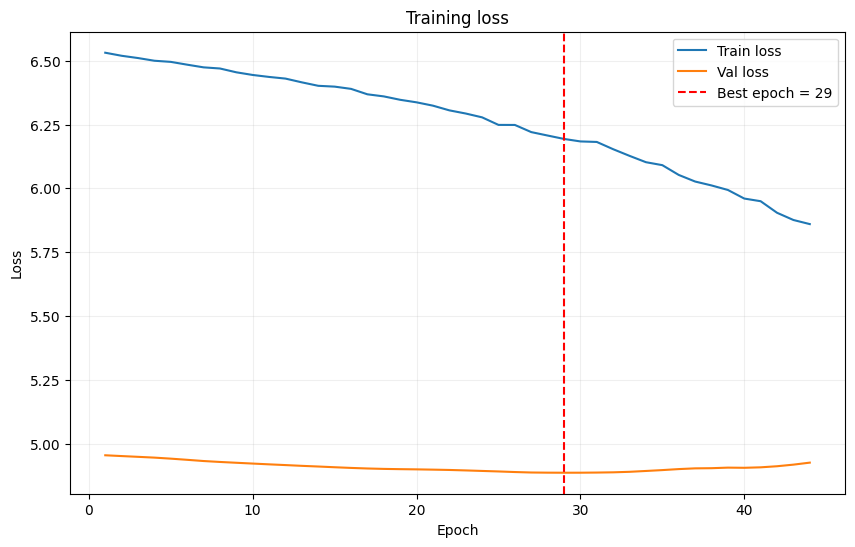

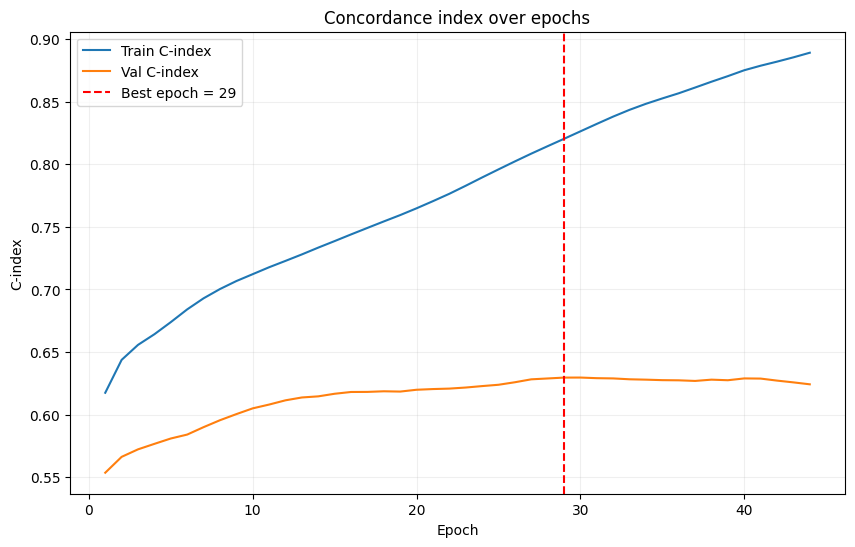

Best restored epoch: 29
Best validation loss: 4.8860


,epoch,train_loss,train_cindex,lr,val_loss,val_cindex,epoch_time_sec,elapsed_time_min
39,40,5.960024,0.875118,0.0003,4.905315,0.628916,0.025839,0.018390
40,41,5.949582,0.878746,0.0003,4.907151,0.628784,0.025645,0.018819
41,42,5.904315,0.881993,0.0003,4.911392,0.627170,0.025595,0.019245
42,43,5.876018,0.885422,0.0003,4.917671,0.625754,0.025362,0.019668
43,44,5.859925,0.889113,0.0003,4.925542,0.624205,0.034144,0.020237


In [20]:

# =========================
# 17. Plot training history
# =========================
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
if "val_loss" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
if best_epoch is not None:
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/plot_gated_TrainingLoss.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_cindex"], label="Train C-index")
if "val_cindex" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_cindex"], label="Val C-index")
if best_epoch is not None:
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Concordance index over epochs")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/plot_gated_Cindex_over_epochs.png", dpi=300)
plt.show()

print(f"Best restored epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
history_df.tail()

In [21]:

# =========================
# 18. Final evaluation
# =========================
train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

print(f"Final Train C-index: {train_ci:.4f}")
print(f"Final Val   C-index: {val_ci:.4f}")

if test_data is not None:
    test_ci = evaluate_cindex(model, test_data, scaler=scaler, device=DEVICE)
    print(f"Final Test  C-index: {test_ci:.4f}")


Final Train C-index: 0.8203
Final Val   C-index: 0.6296
Final Test  C-index: 0.6660


In [22]:
# =========================
# 19. Save model, scaler, history, feature names, and gate summaries
# =========================

OUTPUT_DIR = "/content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path = os.path.join(OUTPUT_DIR, "gated_attention_deepsurv_model.pt")
history_path = os.path.join(OUTPUT_DIR, "gated_attention_deepsurv_training_history.csv")
feature_names_path = os.path.join(OUTPUT_DIR, "gated_attention_deepsurv_feature_names.txt")
scaler_path = os.path.join(OUTPUT_DIR, "gated_attention_deepsurv_scaler.npz")
config_path = os.path.join(OUTPUT_DIR, "gated_attention_deepsurv_config.json")

gate_summary_path = os.path.join(OUTPUT_DIR, "gate_summary.csv")
top_genes_path = os.path.join(OUTPUT_DIR, "top_gated_genes.csv")


# Save model weights
torch.save(model.state_dict(), model_path)


# Save history
history_df.to_csv(history_path, index=False)


# Save feature names
with open(feature_names_path, "w") as f:
    for name in feature_names:
        f.write(f"{name}\n")


# Save scaler
if scaler is not None:
    np.savez(
        scaler_path,
        mean=scaler.mean.detach().cpu().numpy(),
        std=scaler.std.detach().cpu().numpy(),
    )


# Save config
config_to_save = {
    "model_class": model.__class__.__name__,
    "n_features": N_FEATURES,
    "gate_hidden": GATE_HIDDEN,
    "proj_hidden": PROJ_HIDDEN,
    "hidden_layers_sizes": list(HIDDEN_LAYERS),
    "dropout": DROPOUT,
    "gate_activation": GATE_ACTIVATION,
    "standardize": STANDARDIZE,
    "n_epochs": N_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip": GRADIENT_CLIP,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
}
with open(config_path, "w") as f:
    json.dump(config_to_save, f, indent=2)


# Compute and save gate summaries
model.eval()

x_all = torch.tensor(train_data["x"], dtype=torch.float32, device=DEVICE)

if scaler is not None:
    x_all = scaler.transform(x_all)

with torch.no_grad():
    log_risk, gates = model(x_all, return_attention=True)

# gates shape: [B, P]
gates_np = gates.detach().cpu().numpy()

# Mean gate score across all patients
mean_gate_scores = gates_np.mean(axis=0)   # [P]
std_gate_scores = gates_np.std(axis=0)     # [P]

gate_summary_df = pd.DataFrame({
    "gene": feature_names,
    "mean_gate_score": mean_gate_scores,
    "std_gate_score": std_gate_scores,
}).sort_values("mean_gate_score", ascending=False)

top_genes_df = gate_summary_df.head(20).copy()
top_genes_df.insert(0, "rank", range(1, len(top_genes_df) + 1))

gate_summary_df.to_csv(gate_summary_path, index=False)
top_genes_df.to_csv(top_genes_path, index=False)


# Print summary
print("Saved model to:", model_path)
print("Saved history to:", history_path)
print("Saved feature names to:", feature_names_path)
print("Saved config to:", config_path)
print("Saved gate summary to:", gate_summary_path)
print("Saved top gated genes to:", top_genes_path)

if scaler is not None:
    print("Saved scaler to:", scaler_path)
else:
    print("No notebook scaler saved because STANDARDIZE=False.")

Saved model to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_model.pt
Saved history to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_training_history.csv
Saved feature names to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_feature_names.txt
Saved config to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_config.json
Saved gate summary to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gate_summary.csv
Saved top gated genes to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/top_gated_genes.csv
No notebook scaler saved because STANDARDIZE=False.


Top gated genes:


,rank,gene,mean_gate_score,std_gate_score
0,1,MUC15,0.711608,0.080474
1,2,OR10D1P,0.704992,0.078322
2,3,IL12A,0.704451,0.080893
3,4,TBCB,0.698024,0.074103
4,5,TAFA4,0.697891,0.085243
...,...,...,...,...
95,96,ENPP3,0.643519,0.097014
96,97,LINC03007,0.643483,0.080677
97,98,H2AC13,0.643216,0.097577
98,99,FAM151B,0.642779,0.082314


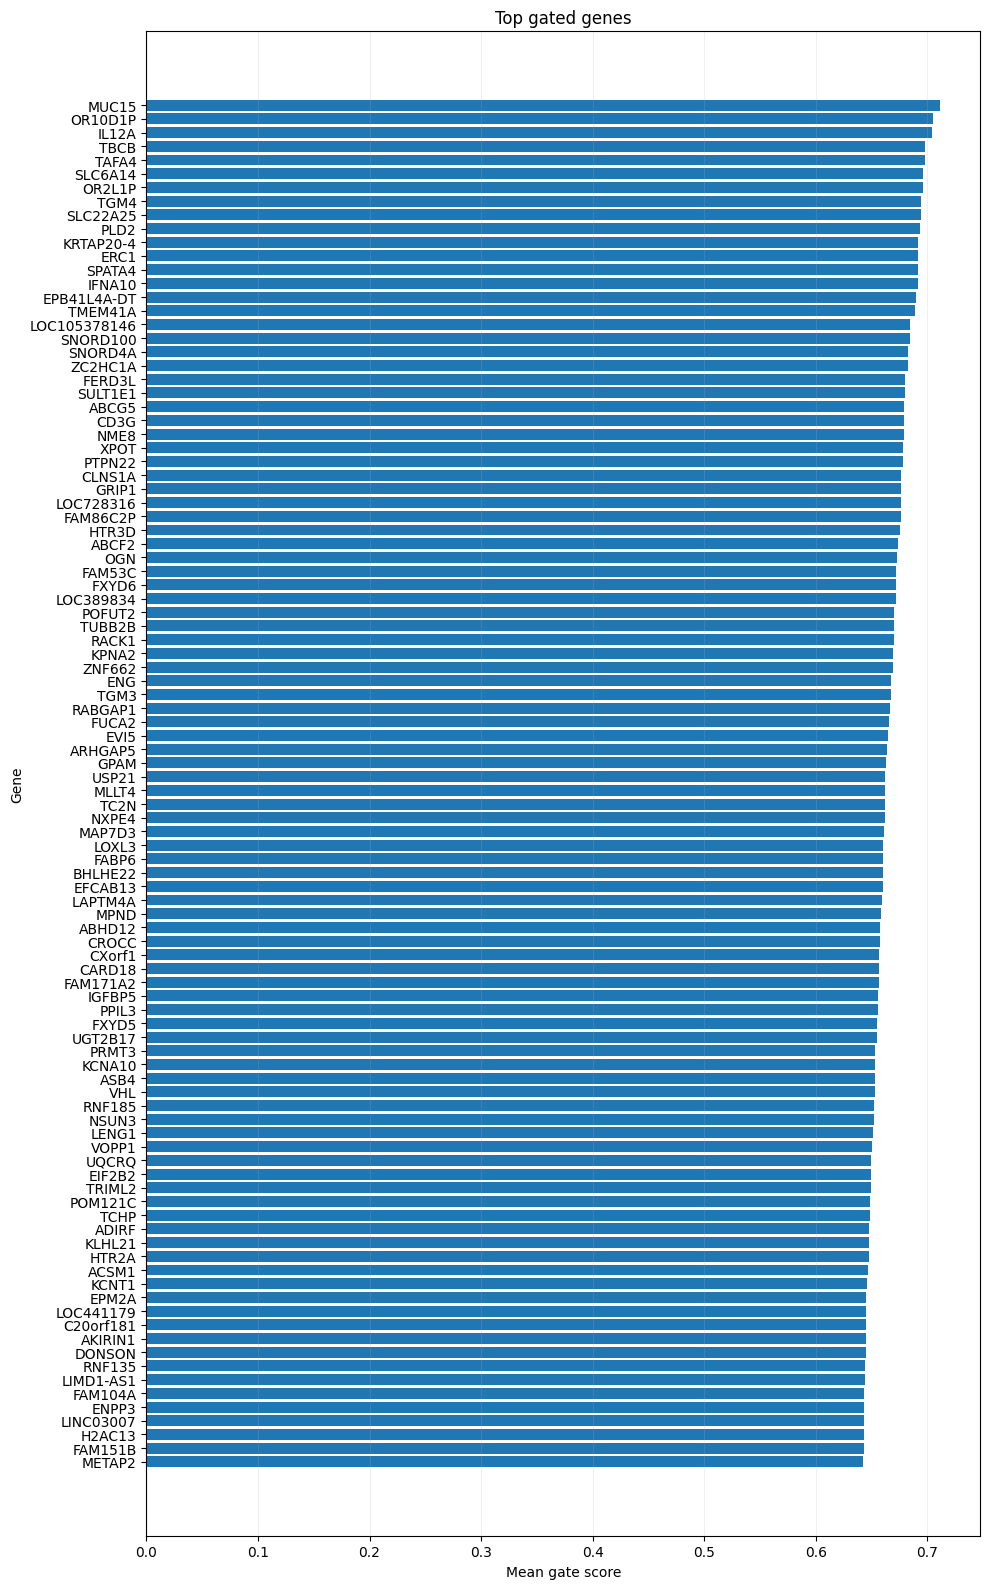

In [23]:
TOP_K = 100

# Put model in eval mode
model.eval()

# Use whichever split you want to summarize
# train_data / val_data / test_data
x_all = torch.tensor(train_data["x"], dtype=torch.float32, device=DEVICE)

# Apply scaler if used
if scaler is not None:
    x_all = scaler.transform(x_all)

# Get gates from the trained residual gated model
with torch.no_grad():
    _, gates = model(x_all, return_attention=True)

# gates shape: [n_patients, n_genes]
gates_np = gates.detach().cpu().numpy()

# Mean and std gate score across patients
mean_gate_scores = gates_np.mean(axis=0)
std_gate_scores = gates_np.std(axis=0)

# Create summary table
gate_summary_df = pd.DataFrame({
    "gene": feature_names,
    "mean_gate_score": mean_gate_scores,
    "std_gate_score": std_gate_scores,
}).sort_values("mean_gate_score", ascending=False).reset_index(drop=True)

# Top-K genes
top_genes_df = gate_summary_df.head(TOP_K).copy()
top_genes_df.insert(0, "rank", range(1, len(top_genes_df) + 1))

# Display table
print("Top gated genes:")
display(top_genes_df)

# Plot
plot_df = top_genes_df.sort_values("mean_gate_score", ascending=True)

plt.figure(figsize=(10, 16))
plt.barh(plot_df["gene"], plot_df["mean_gate_score"])
plt.xlabel("Mean gate score")
plt.ylabel("Gene")
plt.title("Top gated genes")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/plot_top_100genes.png", dpi=300)
plt.show()